In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 818.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


"1.	Dataset Exploration & Audit"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


https://keras.io/api/data_loading/image/

Using the function from here which i already used in my practical 13

In [ ]:
#returns a object stored in train_dataset
train_ds=keras.utils.image_dataset_from_directory(
    directory ='/kaggle/input/intel-image-classification/seg_train/seg_train',
    #in the directory give that of the train folder
    labels='inferred',
    label_mode="int",
    #this assigns zero for cat and 1 for dogs
    batch_size=32,
    image_size=(150,150)
    #cnn model assumes size of images are same however it is not, so we are giving it same size
)

#same for validation data and use test in the directory
validation_ds=keras.utils.image_dataset_from_directory(
    directory ='/kaggle/input/intel-image-classification/seg_test/seg_test',
    #in the directory give that of the test folder
    labels='inferred',
    label_mode="int",
    #this assigns zero for cat and 1 for dogs
    batch_size=32,
    image_size=(150,150)
    #cnn model assumes size of images are same however it is not, so we are giving it same size
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


2.	Data Preparation & Preprocessing"

In [ ]:
train_ds.element_spec

(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [ ]:
import numpy as np
# Extract labels from the training dataset
labels = []
for images, batch_labels in train_ds:
  labels.extend(batch_labels.numpy())

unique_labels, counts = np.unique(labels, return_counts=True)

class_names = train_ds.class_names

print("Land-use categories and their counts:")
for label, count in zip(unique_labels, counts):
  print(f"Category '{class_names[label]}': {count}")

total_samples = len(labels)
print("\nDataset balance:")
for label, count in zip(unique_labels, counts):
  percentage = (count / total_samples) * 100
  print(f"Category '{class_names[label]}': {percentage:.2f}%")

Land-use categories and their counts:
Category 'buildings': 2191
Category 'forest': 2271
Category 'glacier': 2404
Category 'mountain': 2512
Category 'sea': 2274
Category 'street': 2382

Dataset balance:
Category 'buildings': 15.61%
Category 'forest': 16.18%
Category 'glacier': 17.13%
Category 'mountain': 17.90%
Category 'sea': 16.20%
Category 'street': 16.97%


In [ ]:
    pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 18.3 MB/s eta 0:00:00


()


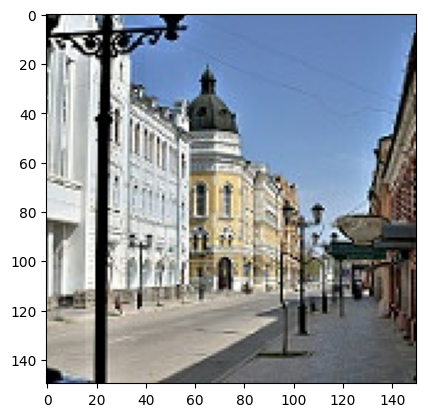

()


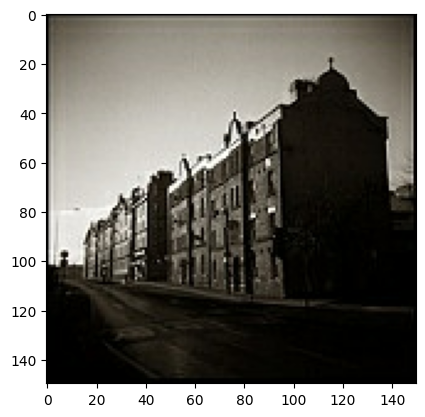

()


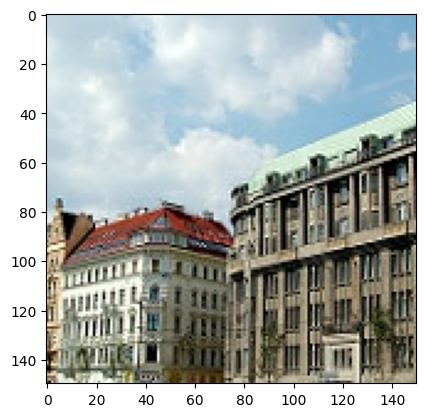

()


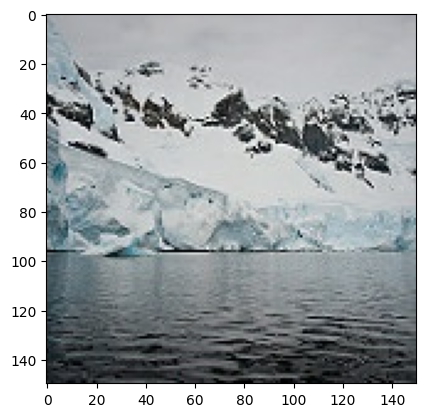

()


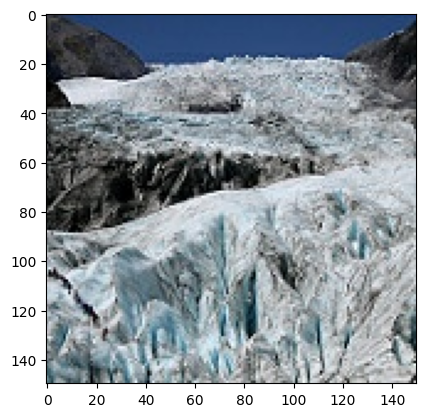

()


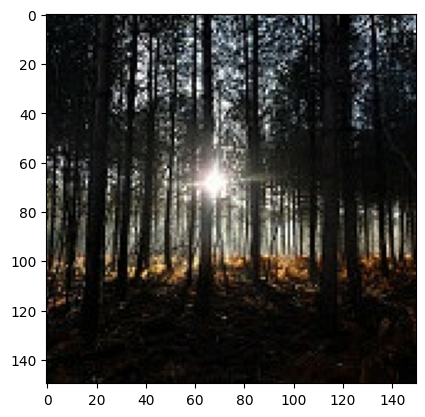

()


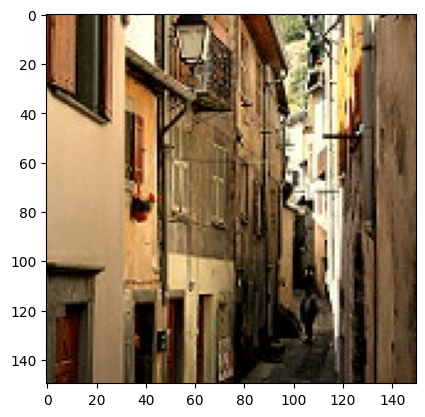

()


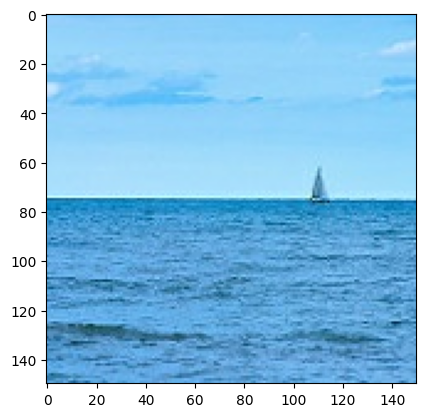

()


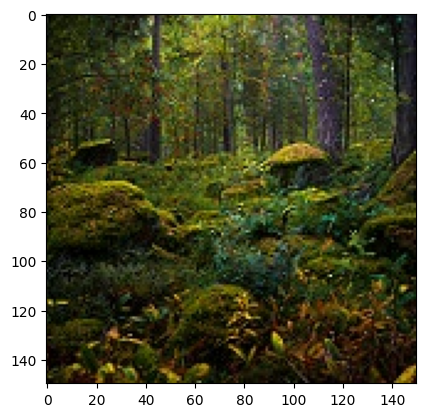

()


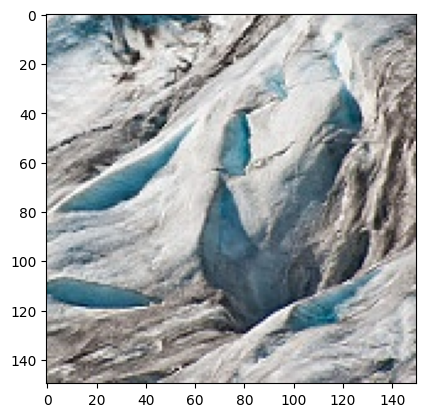

()


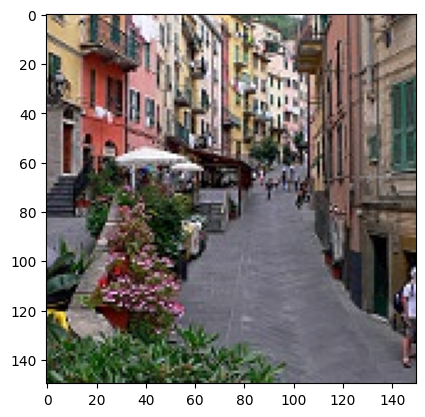

()


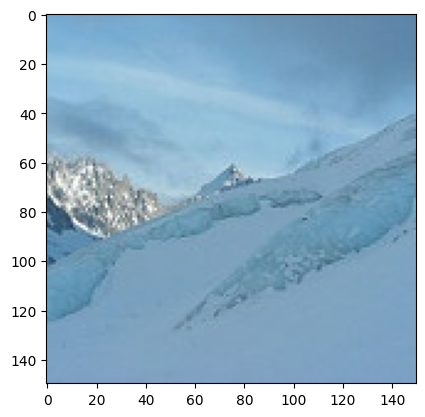

()


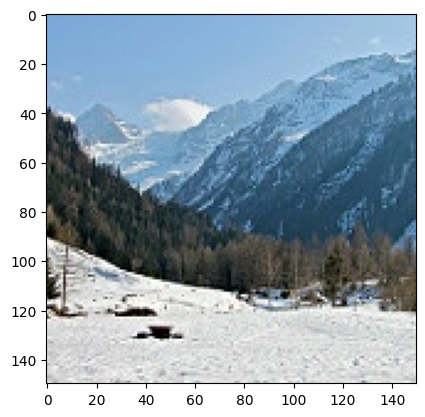

()


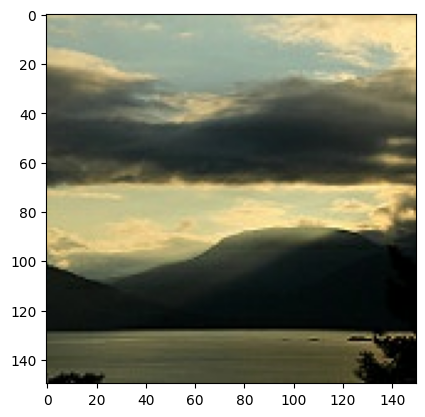

()


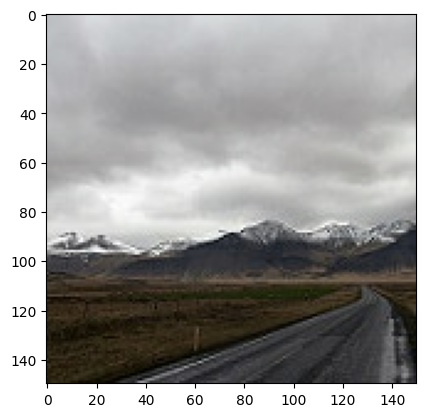

In [ ]:
import matplotlib.pyplot as plt
import cv2
for images, labels in train_ds.take(1):
  for i in range(15):
    plt.imshow(images[i].numpy().astype("uint8"))
    print(labels[i].shape)
    plt.show()

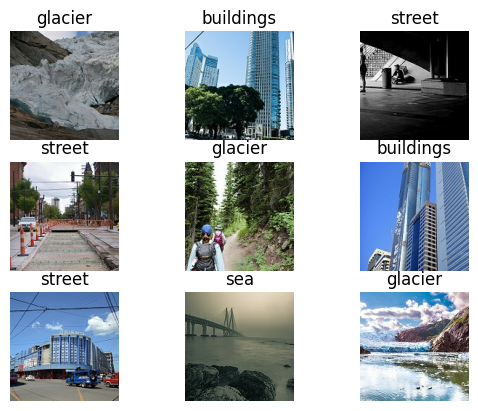

In [ ]:
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

"3.	Feature Reasoning & Model Design"

In [ ]:
from tensorflow.keras import layers
initial_model = keras.Sequential(
 [
 keras.Input(shape=(150, 150, 3)),
 layers.Conv2D(32, 5, strides=2, activation="relu"),
 layers.Conv2D(32, 3, activation="relu"),
 layers.Conv2D(32, 3, activation="relu"),
 ]
)
print("Feature extraction from the model")
feature_extractor = keras.Model(
 inputs=initial_model.inputs,
 outputs=[layer.output for layer in initial_model.layers],
)
print("The feature extractor method is called on test data")
x = tf.ones((1, 150, 150, 3))
features = feature_extractor(x)
print(features)

Feature extraction from the model
The feature extractor method is called on test data
[<tf.Tensor: shape=(1, 73, 73, 32), dtype=float32, numpy=
array([[[[0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         [0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         [0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         [0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         [0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ]],

        [[0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         [0.        , 0.        , 0.        , ..., 0.29603794,
          0.7353934 , 0.4761966 ],
         [0.        , 0.        , 0.        , ..., 0.296

In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


model_context = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

model_context.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_context.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history=model_context.fit(train_ds,epochs=2,validation_data=validation_ds)

Epoch 1/2
439/439 ━━━━━━━━━━━━━━━━━━━━ 240s 545ms/step - accuracy: 0.3354 - loss: 23.4801 - val_accuracy: 0.5510 - val_loss: 1.1332
Epoch 2/2
439/439 ━━━━━━━━━━━━━━━━━━━━ 241s 550ms/step - accuracy: 0.5764 - loss: 1.0649 - val_accuracy: 0.5890 - val_loss: 1.0256


5.	Performance Evaluation & Error Analysis

In [ ]:
for images, labels in validation_ds.take(1):
    break

predictions = model_context.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


In [ ]:
import tensorflow as tf
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

cm=tf.math.confusion_matrix(
    labels,
    predicted_labels,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


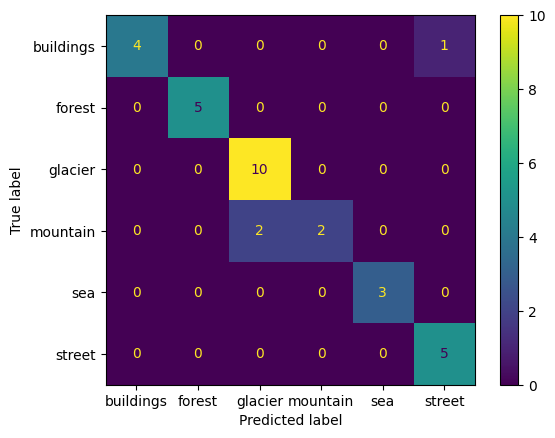

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

cm_np = cm.numpy()
class_names = train_ds.class_names
disp = ConfusionMatrixDisplay(confusion_matrix=cm_np,
                              display_labels=class_names)
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

accuracy = accuracy_score(labels, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

f1_macro = f1_score(labels, predicted_labels, average='macro')
print(f"Macro F1 Score: {f1_macro:.4f}")

Accuracy: 0.7500
Macro F1 Score: 0.7142


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.applications import VGG16
from keras.layers import Dense, Flatten
from keras.models import Model

# Load the VGG16 model with pre-trained weights from ImageNet
# Include_top=False removes the classification layer at the top
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the layers of the base model so they are not trained
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, epochs=1, validation_data=validation_ds)

439/439 ━━━━━━━━━━━━━━━━━━━━ 1340s 3s/step - accuracy: 0.9270 - loss: 0.5180 - val_accuracy: 0.8637 - val_loss: 0.6379


In [ ]:
  !pip install h5py

In [ ]:
 model_context.save('my_model.h5')

In [ ]:
    from google.colab import files
    files.download('my_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

'''
This code notebook was completed by 23IT116 Shah Dev Mineshkumar with the use of Ai or external AI tools
'''